In [70]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, recall_score, precision_score

In [71]:
path = "UCI_credit_default.xls"
df = pd.read_excel(path, header = 1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


The aim of this project is to evaluate credit risk predict whether a client will default on their next payment or not. (Binary classification: Yes/No)

By accurately identifying high-risk clients the institution can choose to not loan to them or manage credit limits to avoid significant losses.

Success of the model will be evaluated primarily by recall (so as to catch as many people that would actually default) and ROC-AUC (to determine the model's overall ability to distinguish between defaulters and non-defaulters).

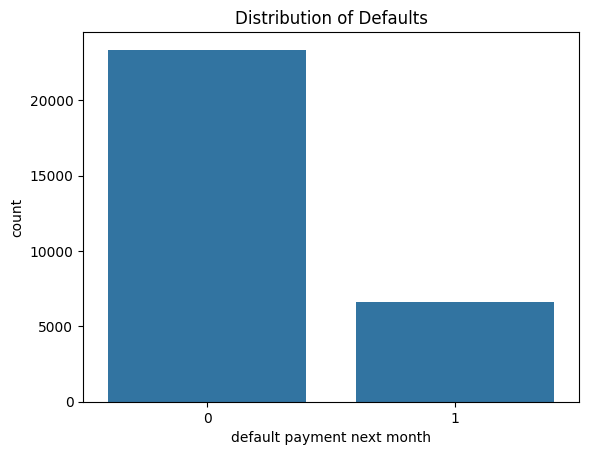

In [72]:
#Checking the distribution of the target variable to check class imbalances.
sns.countplot(data = df, x = 'default payment next month')

plt.title('Distribution of Defaults')

plt.show()

There is a class imbalance in the data, there are more non-defaults than defaults.


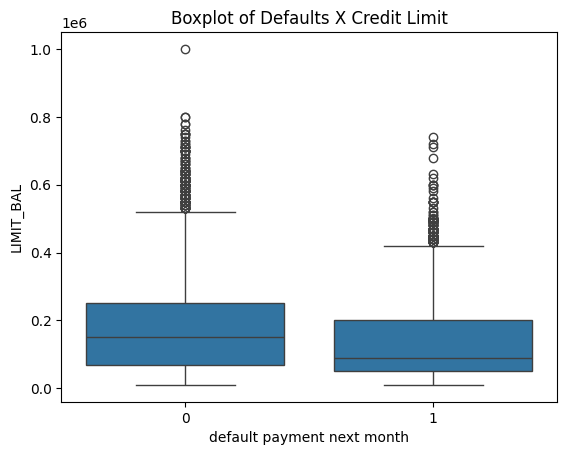

In [73]:
#Observing how defaults vary over a continuous variable - Credit limit (LIMIT_Bal)
sns.boxplot(data = df, x = 'default payment next month', y = 'LIMIT_BAL')

plt.title('Boxplot of Defaults X Credit Limit')

plt.show()

The median of people that default is lower than those that don't default.

In [74]:
# Dropping the ID column so that the model doesn't get confused and assume that it's a factor that affects default chance.
df = df.drop(columns = ['ID'])

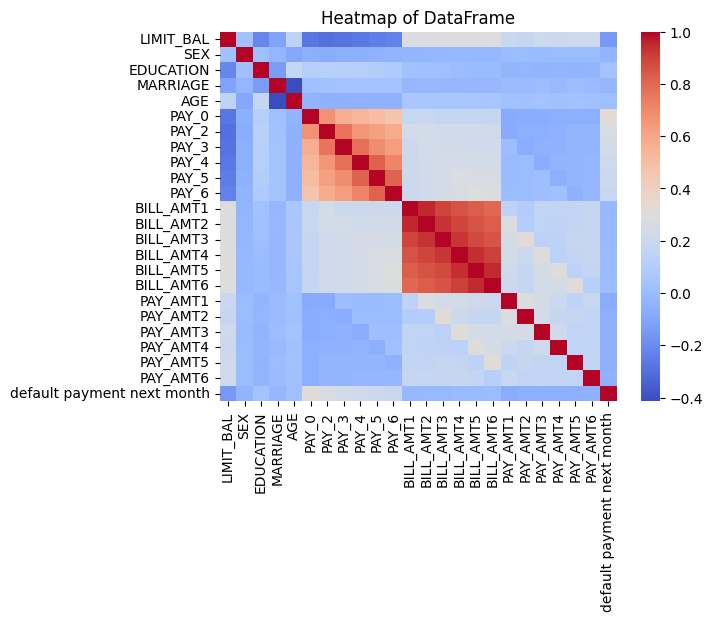

In [75]:
#Heatmap to observe the correlation between the range of variables.
sns.heatmap(df.corr(), cmap = 'coolwarm')

plt.title('Heatmap of DataFrame')

plt.show()

The strongest correlating variable with default payment next month appears to be the credit limit.


In [76]:
#Checking missing values to determine if imputaiton is necessary.
df.isnull().sum()

,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


No missing so there's no need to impute any values, so we can proceed with splitting our data into test and train sets.

In [77]:
# Prepaer data by converting categorial variabls and split data into test/train splits to build decision tree model
df = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'])

X = df.drop(columns = 'default payment next month')
Y = df['default payment next month']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [78]:
# Helper function that makes use of hyperparameters to find the best values for accurate results.
def dtmodel_tester(X_train, y_train, X_test, y_test, depths_list, leaves_list):
    """
    Tests combinations of max_depth and min_samples_leaf for a Decision Tree.
    Returns the best model based on Class 1 Recall.
    """
    best_recall = 0
    best_model = None

    for depth in depths_list:
        for leaf in leaves_list:
            model = DecisionTreeClassifier(max_depth=depth,
                                           min_samples_leaf=leaf,
                                           class_weight='balanced',
                                           random_state=42)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            score = recall_score(y_test, pred, pos_label=1)

            if score > best_recall:
                best_recall = score
                best_model = model

    print(f"Decision Tree - Best Recall: {best_recall:.4f} | Depth: {best_model.max_depth} | Leaf: {best_model.min_samples_leaf}")
    return best_model

In [79]:
def rf_model_tester(X_train, y_train, X_test, y_test, depths_list, leaves_list):
    """
    Tests combinations of max_depth and min_samples_leaf for a Random Forest.
    Returns the best model based on Class 1 Recall.
    """
    best_recall = 0
    best_model = None

    for depth in depths_list:
        for leaf in leaves_list:
            model = RandomForestClassifier(n_estimators=100,
                                           max_depth=depth,
                                           min_samples_leaf=leaf,
                                           class_weight='balanced',
                                           random_state=42)
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            score = recall_score(y_test, pred, pos_label=1)

            if score > best_recall:
                best_recall = score
                best_model = model

    print(f"Random Forest - Best Recall: {best_recall:.4f} | Depth: {best_model.max_depth} | Leaf: {best_model.min_samples_leaf}")
    return best_model

In [80]:
# Building numerous decision tree models with a helper function and then testing their recall to find the best one
depths = [1, 2, 3, 4, 5, 6, 7]
leafs = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

#Assigning the model with the optimized values to a variable
best_dtmodel = dtmodel_tester(X_train, y_train, X_test, y_test, depths, leafs)
pred = best_dtmodel.predict(X_test)
print(f"Precision: {precision_score(y_test, pred):.4f}")

Decision Tree - Best Recall: 0.6021 | Depth: 7 | Leaf: 100
Precision: 0.4427


#Decision Tree Model Testing
I tested numerous combinations of max depth and min sample leaf values. The lower I went in values, the higher my recall until the splits stopped changing because the tree was too shallow. Going higher caused overfitting and dropped recall scores. The function had determined that the best max depth was 3 and best min sample leaf was 1. The recall for these values was 57.95% and precision was 47.82%.

--- Decision Tree Confusion Matrix ---


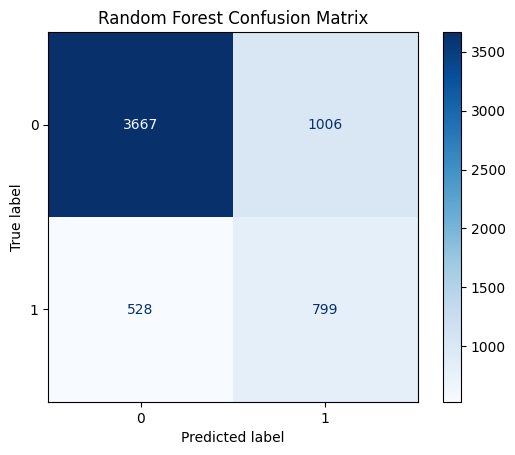


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.78      0.83      4673
           1       0.44      0.60      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.74      0.76      6000



In [81]:
# Analyzing the model with the optimized values
print("--- Decision Tree Confusion Matrix ---")
ConfusionMatrixDisplay.from_estimator(best_dtmodel, X_test, y_test, cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.show()

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, pred))

ROC-AUC Score: 0.693415379375595


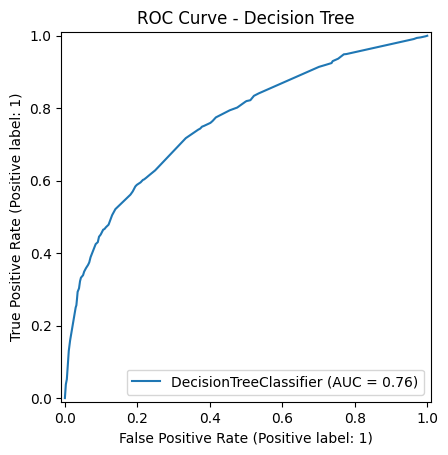

In [85]:
#Testing a second metric (ROC curve) for better validity
auc_score = roc_auc_score(y_test, pred)
print(f"ROC-AUC Score: {auc_score}")

RocCurveDisplay.from_estimator(best_dtmodel, X_test, y_test)
plt.title("ROC Curve - Decision Tree")
plt.show()

#Decision Tree Model Analysis
The Decision Tree model has a good ROC-AUC score of 0.737 and the recall and precision aren't that bad either. However, it might be possible to build a more accurate model with a Random Forest.

In [86]:
# Testing different values once again to find the best ones for the Random Forest model.
depths = [10, 15, 20, None]
leaves = [100, 150, 200, 250]

rf_final = rf_model_tester(X_train, y_train, X_test, y_test, depths, leaves)
y_pred_rf = rf_final.predict(X_test)


Random Forest - Best Recall: 0.6292 | Depth: 10 | Leaf: 250


#Random Forest Model Testing
I tested numerous combinations like the Decision Tree model. A max depth of 10 and min sample leaf of 100 resulted in the most balanced values without sacrificing some Precision and ROC for Recall. It might be possible to optimize the validity by testing more values, however it's not worth the computing time to find the fractional improvements.

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4673
           1       0.47      0.63      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000

Random Forest ROC-AUC Score: 0.7701


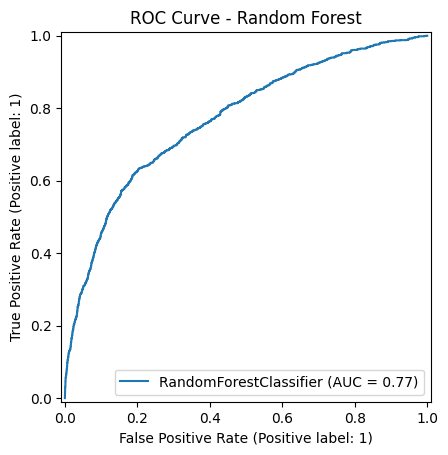


--- Random Forest Confusion Matrix ---


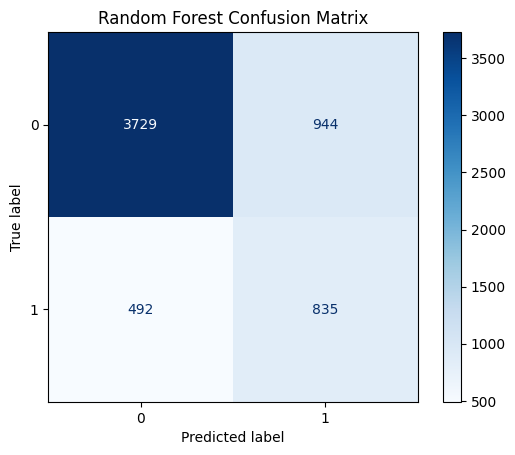

In [87]:
# Building a random forest classifier with the values found from the helper function and testing it's full validity
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

y_pred_probs_rf = rf_final.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, y_pred_probs_rf)
print(f"Random Forest ROC-AUC Score: {rf_auc:.4f}")


RocCurveDisplay.from_estimator(rf_final, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

print("\n--- Random Forest Confusion Matrix ---")
ConfusionMatrixDisplay.from_estimator(rf_final, X_test, y_test, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

#Random Forest Model Analysis
The Random Forest model boasts superior recall and ROC scores at a minimal precision expense. We successfully increased the Class 1 Recall from 58.0% to 61.6% and the overall ROC-AUC from 0.737 to 0.774, at a negligible precision expense (47.8% down to 47.0%).

/tmp/ipython-input-148/874063542.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')


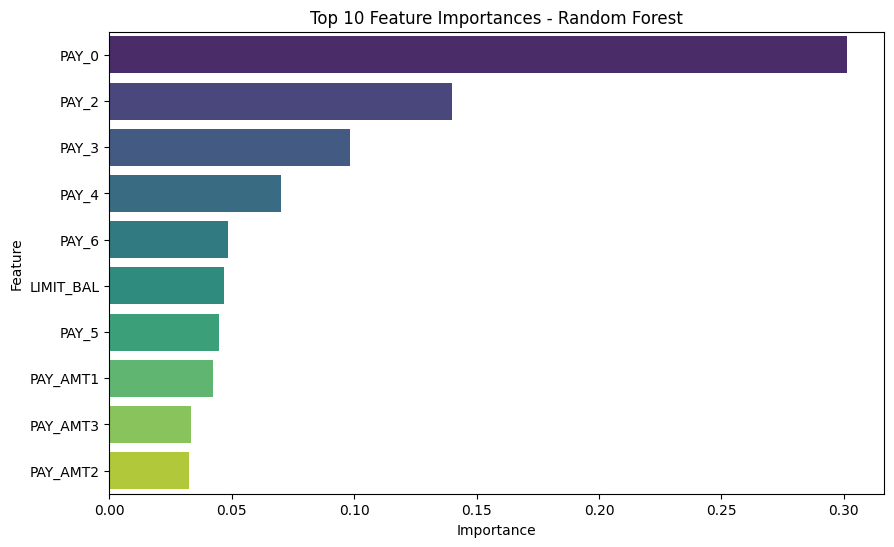

In [88]:
"""
Extracting the most important features from the random forest to determine the factors
that are most likely to cause a person to default and watch out for
"""

importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_final.feature_importances_})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances - Random Forest')
plt.show()

#Final Summary


*   The goal was to predict credit card defaults to help the institution minimize the risk of financial losses. The data set that was analyzed, the UCI Credit Default Data Set, contained information on numerous variables such as age, credit limit, missed payment collected from August 2005 to September 2005 in Taiwan.

*   After testing numerous Decision Trees and Random Forests, the Random Forest model performed the best. After hyperparameter tuning the values that resulted in the best model was a max depth of 10 and minimum leaf sample of 100. That Random Forest had a Recall of 61.6%, Precision of 46.67%, and it's ROC-AUC of 77.4%, catching majority of the true defaults without overly penalizing good customers.

*   The key drivers of customer defaults were the repayment status as of September 2005, the repayment status as of August 2005, and if they had a payment delay for 9 months or above. Therefore, these should be the factors that an institution should prioritize to accurately manage credit limits and avoid the risk of a credit card client defaulting on their payment.




